## VLM 스크래치 코드

하이퍼파라미터 설정

In [3]:
import os
import torch, torch.nn as nn
from torch.nn import functional as F
from PIL import Image
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

batch_size = 64
block_size = 64 
max_iters = 78   # STL10 train=5000장 / batch_size=64 ≈ 78 (1 epoch = 데이터 1회 순회)
eval_interval = 20
learning_rate = 1e-3
epochs = 30
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 50  # val loss 노이즈 감소: 50배치 × 16 = 800샘플
num_blks = 4
head_size = 16
n_embd = 256
n_head = 8
n_layer = 6
dropout = 0.1
img_size = 128
patch_size = 16
image_embed_dim = 512
emb_dropout = blk_dropout = 0.1


데이터셋 로드 (STL-10)

In [4]:
print("데이터셋을 다운로드 및 준비 중입니다...")
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)), # 해상도 키우기
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# torchvision에서 제공하는 STL10 사용 (96x96 고해상도 이미지). https://cs.stanford.edu/~acoates/stl10/
cur_module_folder = "./"
data_folder = os.path.join(cur_module_folder, 'data')
train_data = datasets.STL10(root=data_folder, split='train', download=True, transform=transform)
val_data = datasets.STL10(root=data_folder, split='test', download=True, transform=transform)


데이터셋을 다운로드 및 준비 중입니다...


어휘 사전(Vocab) 구축

In [ ]:
# 프롬프트와 STL10의 10개 클래스명만으로 Character-level Vocab 생성
classes = train_data.classes # ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
base_prompt = "Q: what is this? A: "
all_text = base_prompt + "".join(classes)
chars = sorted(list(set(all_text)))

stoi = { ch:i for i,ch in enumerate(chars) }
stoi['<pad>'] = len(chars)
itos = { i:ch for i,ch in enumerate(chars) }
itos[len(chars)] = '<pad>'
encode = lambda s: [stoi.get(c, stoi['<pad>']) for c in s]
decode = lambda l: ''.join([itos.get(i, '') for i in l])
vocab_size = len(stoi.keys())


ViT 모델 아키텍처 정의  

In [ ]:
class PatchEmbeddings(nn.Module): # 이미지 패치를 임베딩 벡터로 변환
    def __init__(self, img_size=128, patch_size=16, hidden_dim=256):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=3, out_channels=hidden_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, X):
        X = self.conv(X)
        X = X.flatten(2) 
        X = X.transpose(1, 2) 
        return X

class Head(nn.Module): # 트랜스포머 블록 구성 요소 (어텐션 헤드)
    def __init__(self, n_embd, head_size, dropout=0.1, is_decoder=False):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)     # 키 벡터 생성
        self.query = nn.Linear(n_embd, head_size, bias=False)   # 쿼리 벡터 생성
        self.value = nn.Linear(n_embd, head_size, bias=False)   # 값 벡터 생성
        self.dropout = nn.Dropout(dropout)                      # 어텐션 가중치 드롭아웃
        self.is_decoder = is_decoder                            # 디코더 모드에서는 미래 토큰을 마스킹하여 자기회귀적 예측이 가능하도록 함

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (C**-0.5) # 유사도 계산 및 스케일링
        if self.is_decoder:
            tril = torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))
            wei = wei.masked_fill(tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module): # 트랜스포머 블록 구성 요소 (멀티헤드 어텐션)
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()
        assert n_embd % num_heads == 0, "n_embd must be divisible by num_heads" # 각 헤드가 동일한 차원을 갖도록 보장
        self.heads = nn.ModuleList([Head(n_embd, n_embd // num_heads, dropout, is_decoder) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)   # 멀티헤드 어텐션 출력을 원래 임베딩 차원으로 투영
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class Block(nn.Module): # 트랜스포머 블록 (멀티헤드 어텐션 + 피드포워드 네트워크)
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)     # 어텐션 전에 레이어 정규화
        self.attn = MultiHeadAttention(n_embd, num_heads, dropout, is_decoder) # 멀티헤드 어텐션
        self.ln2 = nn.LayerNorm(n_embd)     # 피드포워드 네트워크 전에 레이어 정규화
        self.ffn = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class ViT(nn.Module): # 비전 트랜스포머 모델
    def __init__(self, img_size, patch_size, num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout):
        super().__init__()
        self.patch_embedding = PatchEmbeddings(img_size, patch_size, num_hiddens)   # 이미지 패치를 임베딩 벡터로 변환
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))               # 클래스 토큰 초기화 (학습 가능한 파라미터)
        num_patches = (img_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, num_hiddens))  # 위치 임베딩 초기화 (학습 가능한 파라미터)
        self.dropout = nn.Dropout(emb_dropout)
        self.blocks = nn.ModuleList([Block(num_hiddens, num_heads, blk_dropout, is_decoder=False) for _ in range(num_blks)])
        self.layer_norm = nn.LayerNorm(num_hiddens) # 최종 레이어 정규화

    def forward(self, X):
        x = self.patch_embedding(X)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.layer_norm(x[:, 0]) # 클래스 토큰의 최종 임베딩 반환

class MultiModalProjector(nn.Module): # 이미지 임베딩을 텍스트 임베딩 차원으로 투영하는 모듈
    def __init__(self, n_embd, image_embed_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(image_embed_dim, 4 * image_embed_dim), nn.GELU(), nn.Linear(4 * image_embed_dim, n_embd), nn.Dropout(dropout))
    def forward(self, x):
        return self.net(x)


디코더와 VLM 구조 정의

In [ ]:
class DecoderLanguageModel(nn.Module): # 디코더 언어 모델
    def __init__(self, n_embd, image_embed_dim, vocab_size, num_heads, n_layer, use_images=False):
        super().__init__()
        self.use_images = use_images
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)   # 텍스트 토큰을 임베딩 벡터로 변환
        self.position_embedding_table = nn.Embedding(1000, n_embd)      # 위치 임베딩 초기화 (학습 가능한 파라미터)
        if use_images:
            self.image_projection = MultiModalProjector(n_embd, image_embed_dim)
        self.blocks = nn.Sequential(*[Block(n_embd, num_heads, is_decoder=True) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)                # 최종 레이어 정규화
        self.lm_head = nn.Linear(n_embd, vocab_size)    # 언어 모델 헤드

    def forward(self, idx, image_embeds=None, targets=None):
        tok_emb = self.token_embedding_table(idx)           # 텍스트 토큰을 임베딩 벡터로 변환
        if self.use_images and image_embeds is not None:    # 이미지 임베딩을 텍스트 임베딩 차원으로 투영하여 토큰 임베딩과 결합
            img_emb = self.image_projection(image_embeds).unsqueeze(1)
            tok_emb = torch.cat([img_emb, tok_emb], dim=1)
        pos_emb = self.position_embedding_table(torch.arange(tok_emb.size(1), device=device)).unsqueeze(0)          # 위치 임베딩 추가
        x = self.blocks(tok_emb + pos_emb)      # 트랜스포머 블록 통과
        logits = self.lm_head(self.ln_f(x))     # 최종 레이어 정규화 후 언어 모델 헤드로 클래스 확률 계산
        if targets is not None: # 손실 계산 
            if self.use_images and image_embeds is not None:
                targets = torch.cat([torch.full((idx.size(0), 1), -100, dtype=torch.long, device=device), targets], dim=1)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
            return logits, loss
        return logits

    def generate(self, idx, image_embeds, max_new_tokens):
        generated = idx # 초기 입력 토큰 시퀀스
        current_output = torch.cat([self.image_projection(image_embeds).unsqueeze(1), self.token_embedding_table(idx)], dim=1) if self.use_images and image_embeds is not None else self.token_embedding_table(idx) # 이미지 임베딩을 텍스트 임베딩 차원으로 투영하여 토큰 임베딩과 결합
        
        for _ in range(max_new_tokens): # 최대 새 토큰 수만큼 반복하여 토큰 생성
            current_output_pos = current_output + self.position_embedding_table(torch.arange(current_output.size(1), device=device)).unsqueeze(0)          # 위치 임베딩 추가
            for block in self.blocks:
                current_output_pos = block(current_output_pos)                      # 트랜스포머 블록 통과
            logits = self.lm_head(self.ln_f(current_output_pos[:, -1, :]))          # 최종 레이어 정규화 후 언어 모델 헤드로 클래스 확률 계산
            idx_next = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)  # 다음 토큰 샘플링
            generated = torch.cat((generated, idx_next), dim=1)     # 생성된 토큰 시퀀스에 다음 토큰 추가
            current_output = torch.cat((current_output, self.token_embedding_table(idx_next)), dim=1)       # 다음 토큰 임베딩을 현재 출력에 추가하여 다음 반복에서 사용
        return generated

class VisionLanguageModel(nn.Module): # 비전-언어 모델 (ViT + 디코더 언어 모델)
    def __init__(self, n_embd, image_embed_dim, vocab_size, n_layer, img_size, patch_size, num_heads, num_blks, emb_dropout, blk_dropout):
        super().__init__()
        self.vision_encoder = ViT(img_size, patch_size, image_embed_dim, num_heads, num_blks, emb_dropout, blk_dropout) # ViT를 이미지 인코더로 사용
        self.decoder = DecoderLanguageModel(n_embd, image_embed_dim, vocab_size, num_heads, n_layer, use_images=True) # 디코더 언어 모델 (이미지 임베딩을 입력으로 사용)

    def forward(self, img_array, idx, targets=None):
        return self.decoder(idx, self.vision_encoder(img_array), targets) if targets is not None else self.decoder(idx, self.vision_encoder(img_array))

    def generate(self, img_array, idx, max_new_tokens):
        return self.decoder.generate(idx, self.vision_encoder(img_array), max_new_tokens)


데이터 파이프라인 정의

In [ ]:
def get_batch(dataset, batch_size):
    # Dataset에서 무작위로 인덱스를 뽑아 배치를 만듭니다
    idx = torch.randint(0, len(dataset), (batch_size,))
    images = []
    texts = []
    
    for i in idx:
        img, label = dataset[i]
        images.append(img)
        
        class_name = dataset.classes[label]
        text_str = f"Q: what is this? A: {class_name}"
        texts.append(torch.tensor(encode(text_str), dtype=torch.long))
        
    images = torch.stack(images).to(device)
    max_length = max(len(t) for t in texts)

    padded_text = torch.full((batch_size, max_length), fill_value=stoi['<pad>'], dtype=torch.long, device=device)
    for i, text in enumerate(texts):
        padded_text[i, :len(text)] = text

    targets = torch.cat([padded_text[:, 1:], torch.full((batch_size, 1), fill_value=stoi['<pad>'], dtype=torch.long, device=device)], dim=1)

    # 프롬프트 부분의 loss를 마스킹: 클래스명 예측 loss만 학습에 반영
    # (프롬프트를 암기하는 shortcut learning 방지)
    prompt_len = len(encode("Q: what is this? A: "))
    targets[:, :prompt_len - 1] = -100  # targets는 1칸 shift이므로 prompt_len-1까지 마스킹. -100은 cross_entropy에서 무시되는 인덱스. 관례적으로 -100을 사용하는 이유는 유효한 vocab index가 절대 음수가 될 수 없기 때문에 "무시할 위치"의 sentinel 값으로 쓰기 적합하기 때문. PyTorch가 이 값을 기본값으로 채택하면서 업계 표준처럼 굳어짐.

    return images, padded_text, targets

def estimate_loss(model, dataset):
    losses = []
    model.eval()
    with torch.no_grad():
        for _ in range(eval_iters):
            images, idx, targets = get_batch(dataset, batch_size=16)
            _, loss = model(images, idx, targets)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

모델 학습 

In [9]:
print(f"Vocab size: {vocab_size} | Device: {device}")

model = VisionLanguageModel(n_embd, image_embed_dim, vocab_size, n_layer, img_size, patch_size, n_head, num_blks, emb_dropout, blk_dropout)
model.to(device)

print("모델 학습 시작 (STL-10)")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
model.to(device)
best_val_loss = float('inf')
best_model_path = os.path.join(cur_module_folder, "vlm_stl10_best.pt")
for epoch in range(epochs):
    model.train()
    for _ in range(max_iters):
        images, idx, targets = get_batch(train_data, batch_size)
        optimizer.zero_grad()
        logits, loss = model(images, idx, targets)
        loss.backward()
        optimizer.step()
        
        if _ % eval_interval == 0:
            print(f"Epoch {epoch+1} | Iteration {_}: Train Loss = {loss.item():.4f}")
            
    val_loss = estimate_loss(model, val_data)
    print(f"--> Validation Loss after epoch {epoch+1}: {val_loss:.4f}\n")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  [Best model saved] val_loss={best_val_loss:.4f}\n")

# 최적 모델 로드
model.load_state_dict(torch.load(best_model_path, map_location=device))
print(f"Best val_loss={best_val_loss:.4f} 모델로 추론합니다.")


print("\nQA 추론 테스트")
model.eval()

Vocab size: 26 | Device: cuda
모델 학습 시작 (STL-10)
Epoch 1 | Iteration 0: Train Loss = 3.5768
Epoch 1 | Iteration 20: Train Loss = 0.3927
Epoch 1 | Iteration 40: Train Loss = 0.2797
Epoch 1 | Iteration 60: Train Loss = 0.2611
--> Validation Loss after epoch 1: 0.2590

  [Best model saved] val_loss=0.2590

Epoch 2 | Iteration 0: Train Loss = 0.2363
Epoch 2 | Iteration 20: Train Loss = 0.2368
Epoch 2 | Iteration 40: Train Loss = 0.2510
Epoch 2 | Iteration 60: Train Loss = 0.2414
--> Validation Loss after epoch 2: 0.2797

Epoch 3 | Iteration 0: Train Loss = 0.2502
Epoch 3 | Iteration 20: Train Loss = 0.2335
Epoch 3 | Iteration 40: Train Loss = 0.2364
Epoch 3 | Iteration 60: Train Loss = 0.2298
--> Validation Loss after epoch 3: 0.2529

  [Best model saved] val_loss=0.2529

Epoch 4 | Iteration 0: Train Loss = 0.2251
Epoch 4 | Iteration 20: Train Loss = 0.2173
Epoch 4 | Iteration 40: Train Loss = 0.2451
Epoch 4 | Iteration 60: Train Loss = 0.2323
--> Validation Loss after epoch 4: 0.2467

  [B

VisionLanguageModel(
  (vision_encoder): ViT(
    (patch_embedding): PatchEmbeddings(
      (conv): Conv2d(3, 512, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (attn): MultiHeadAttention(
          (heads): ModuleList(
            (0-7): 8 x Head(
              (key): Linear(in_features=512, out_features=64, bias=False)
              (query): Linear(in_features=512, out_features=64, bias=False)
              (value): Linear(in_features=512, out_features=64, bias=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (proj): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=512, out_fe

테스트 데이터셋에서 무작위 이미지 추출 및 테스트

In [12]:
test_idx = torch.randint(0, len(val_data), (1,)).item()
test_img, test_label = val_data[test_idx]
true_class_name = val_data.classes[test_label]
test_img_tensor = test_img.unsqueeze(0).to(device) # 배치 차원 추가

prompt = "Q: what is this? A: "
prompt_idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)

with torch.no_grad():
    output_ids = model.generate(test_img_tensor, prompt_idx, max_new_tokens=20) # 단어 길이 고려하여 토큰 수 조정

generated_result = decode(output_ids[0].tolist()).replace('<pad>', '') 
answer_text = generated_result.replace(prompt, "").strip()

print(f"실제 정답: {true_class_name}")
print(f"모델 답변: {answer_text}")


실제 정답: monkey
모델 답변: monkey


결과 시각화

결과 이미지가 './vlm_stl10_output.png'로 저장되었습니다!


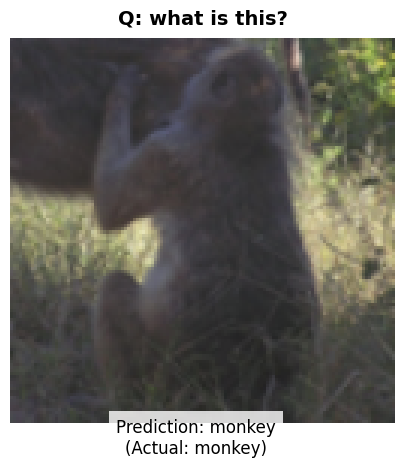

In [13]:
img_np = test_img_tensor[0].cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img_np)
plt.axis('off')
plt.title("Q: what is this?", fontsize=14, fontweight='bold', pad=10) 
plt.figtext(0.5, 0.05, f"Prediction: {answer_text}\n(Actual: {true_class_name})", ha="center", fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

output_fname = os.path.join(cur_module_folder, "vlm_stl10_output.png")
plt.savefig(output_fname, bbox_inches='tight')
print(f"결과 이미지가 '{output_fname}'로 저장되었습니다!")
plt.show()